# Lesson 2 : LangGraph Components

In [28]:
# pip install langchain-tavily

In [29]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI

In [30]:
from langchain_tavily import TavilySearch

## Tavily Search Tool

[Tavily](https://tavily.com) is a search engine built specifically for AI agents. Unlike general web search APIs, it returns clean, structured results optimized for LLM consumption — no HTML parsing needed.

To use it you need a free API key:
1. Sign up at [app.tavily.com](https://app.tavily.com)
2. Copy your API key
3. Add it to your `.env` file: 

In [31]:
from dotenv import load_dotenv
_ = load_dotenv()

In [32]:
tool = TavilySearch(max_results=4) #increased number of results
print(type(tool))
print(tool.name)

<class 'langchain_tavily.tavily_search.TavilySearch'>
tavily_search


> If you are not familiar with python typing annotation, you can refer to the [python documents](https://docs.python.org/3/library/typing.html).

In [8]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

> Note: in `take_action` below, some logic was added to cover the case that the LLM returned a non-existent tool name. Even with function calling, LLMs can still occasionally hallucinate. Note that all that is done is instructing the LLM to try again! An advantage of an agentic organization.

In [9]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm", # node where the edge starts
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [33]:
prompt = """You are a smart research assistant. Use the search engine to look up information. 
You are allowed to make multiple calls (either together or in sequence). 
Only look up information when you are sure of what you want. 
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOpenAI(model="gpt-3.5-turbo")  #reduce inference cost
abot = Agent(model, [tool], system=prompt)

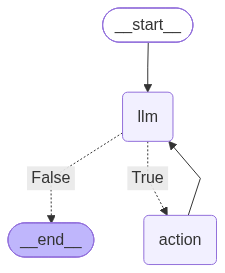

In [35]:
from IPython.display import Image

Image(abot.graph.get_graph().draw_mermaid_png())

In [36]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'current weather in San Francisco', 'search_depth': 'fast'}, 'id': 'call_s4fZHgUqmFMHG8QKEBt3TQqV', 'type': 'tool_call'}
Back to the model!


In [37]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 1326, 'total_tokens': 1351, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-E8krk0evyA8nwjQx4M7fpNB5rMOUp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fc752-3a09-7271-90ee-f5a4ce9d899e-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current weather in San Francisco', 'search_depth': 'fast'}, 'id': 'call_s4fZHgUqmFMHG8QKEBt3TQqV', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'i

In [38]:
result['messages'][-1].content

'The current weather in San Francisco is around 20 degrees Celsius with a probability of precipitation at 0%. There is plenty of sunshine until the evening, with a strong breeze expected later.'

In [39]:
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'current weather in San Francisco', 'search_depth': 'fast'}, 'id': 'call_ruI7Nx3H5dvNJflUsL9tY61M', 'type': 'tool_call'}
Calling: {'name': 'tavily_search', 'args': {'query': 'current weather in Los Angeles', 'search_depth': 'fast'}, 'id': 'call_AFoUI5a6pk7XH2GdjuZbk6EB', 'type': 'tool_call'}
Back to the model!


In [40]:
result['messages'][-1].content

'The current weather in San Francisco is around 20 degrees Celsius with plenty of sunshine. The temperature is expected to rise to 29 degrees during the day. There is a strong breeze later in the day, and the probability of precipitation is low.\n\nIn Los Angeles, the current temperature is around 22 degrees Celsius. The weather is mostly cloudy with a slight chance of precipitation. The temperature is expected to reach 30 degrees in the afternoon with a low probability of precipitation.'

In [44]:
# Note, the query was modified to produce more consistent results. 
# Results may vary per run and over time as search information and models change.

query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

model = ChatOpenAI(model="gpt-4o")  # requires more advanced model
abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search', 'args': {'query': 'Super Bowl 2024 winner'}, 'id': 'call_HaOP7aMwiDlJT1THH54kRGwP', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search', 'args': {'query': 'Kansas City Chiefs headquarters location'}, 'id': 'call_JaTfEv1yqgR2pvRuYIXQsMjq', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search', 'args': {'query': 'GDP of Kansas State 2024'}, 'id': 'call_JrpCMPVqn7qQXO6yUHVoWtdw', 'type': 'tool_call'}
Back to the model!


In [45]:
print(result['messages'][-1].content)

1. **Who won the Super Bowl in 2024?**
   - The Kansas City Chiefs won the Super Bowl in 2024.

2. **In what state is the winning team's headquarters located?**
   - The Kansas City Chiefs' headquarters is located in Olathe, Kansas.

3. **What is the GDP of that state?**
   - The GDP of Kansas in 2024 was approximately $185.72 billion USD.
